# Model

In [ ]:
from topological_insulator import Problem

structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "honeycomb.json"
material_path = "../../../../../topological_insulator/data/cases/"
material_name = "silicene.json"

problem = Problem(structure_path=structure_path, structure_name=structure_name,
                  material_path=material_path, material_name=material_name
)

In [13]:
location = "edge"
problem.setup(
    N_r = 35, # size of lattice in real space
    N_k = 400, # reciprocal space discretization
    location = location,
    BZ="extended"
)

Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.


In [14]:
g = problem.geometry
tb_edge = problem.hamiltonian["edge"]["tight_binding"]

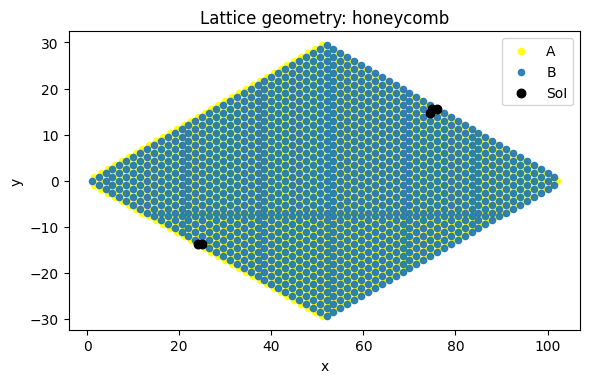

In [15]:
edge_sites = [0, 1, -3, -2, -1]
g.plot_lattice(tb_edge.sublattice_idxs[edge_sites])

In [16]:
problem.run(
    H_type="reciprocal"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!


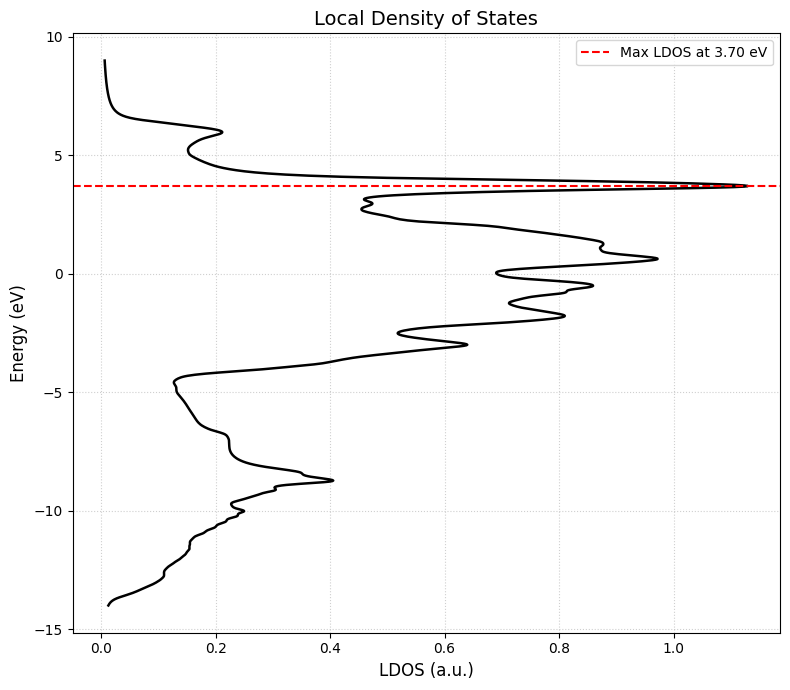

In [17]:
invariants = problem.hamiltonian["edge"]["topological_invariants"]
LDOS, E = invariants.get_local_density_of_states(
    site_idx = 0,
    E_max = 9, 
    E_min = -14,
    eta = 0.15
)

invariants.plot_density_of_states(LDOS, E)

In [18]:
import numpy as np
k_target = np.pi/2
edge_bands = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=k_target, threshold=0.21)
print(edge_bands)

[np.int64(72), np.int64(73), np.int64(124), np.int64(125), np.int64(344), np.int64(345), np.int64(358), np.int64(359), np.int64(478), np.int64(479), np.int64(480), np.int64(481)]


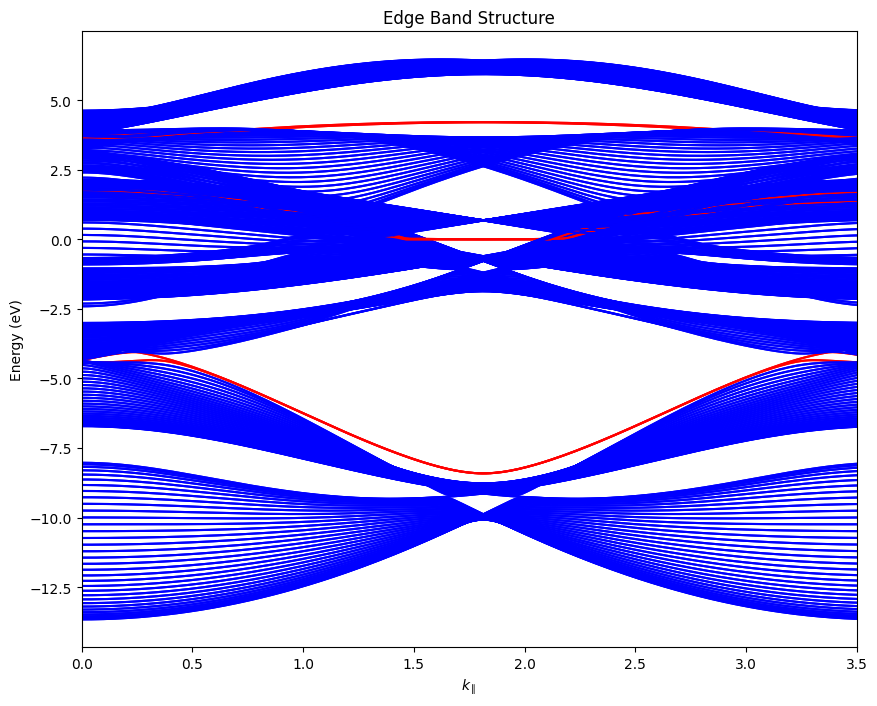

In [19]:
tb_edge.plot_dispersion(g, edge_bands=edge_bands, x_max=3.5, x_min=0)

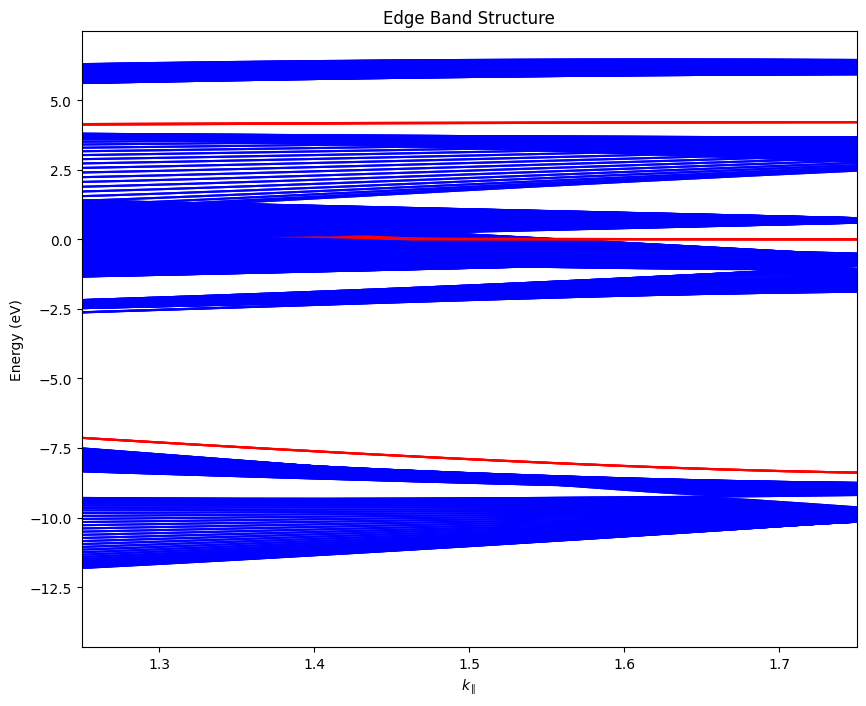

In [20]:
tb_edge.plot_dispersion(g, edge_bands=edge_bands, x_max=1.75, x_min=1.25)

Total norm: 1.000000


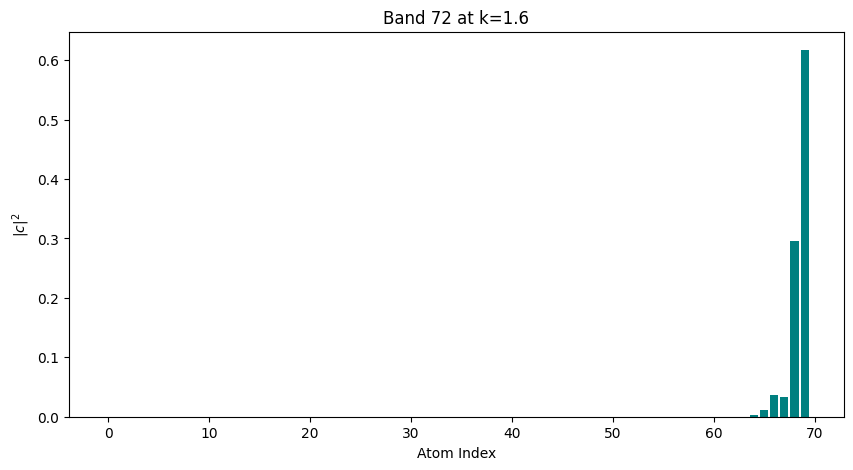

Total norm: 1.000000


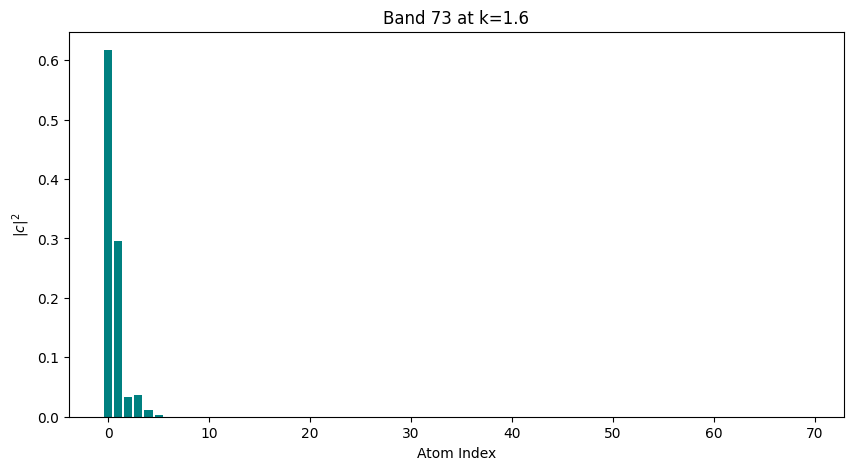

Total norm: 1.000000


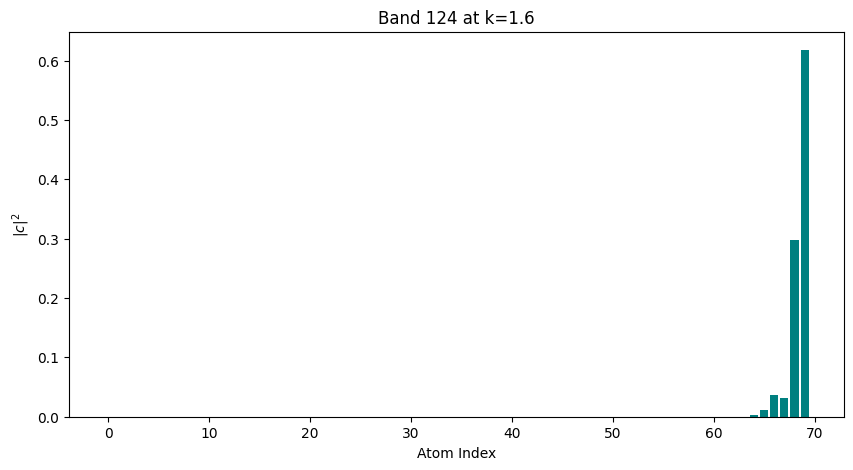

Total norm: 1.000000


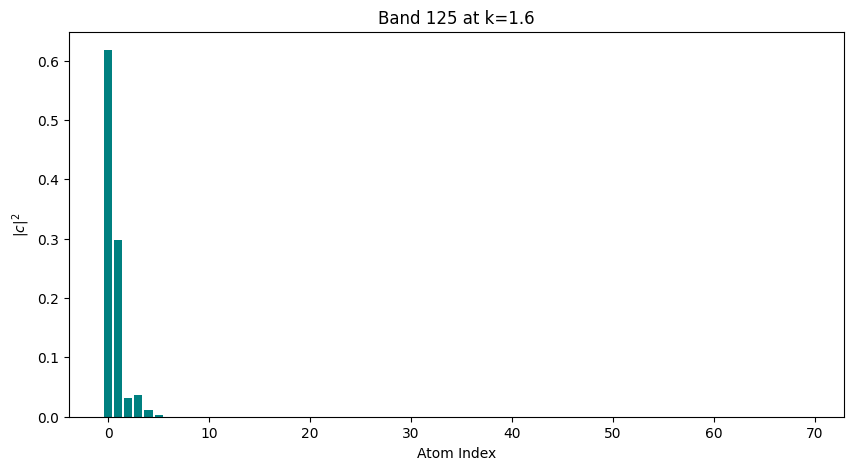

Total norm: 1.000000


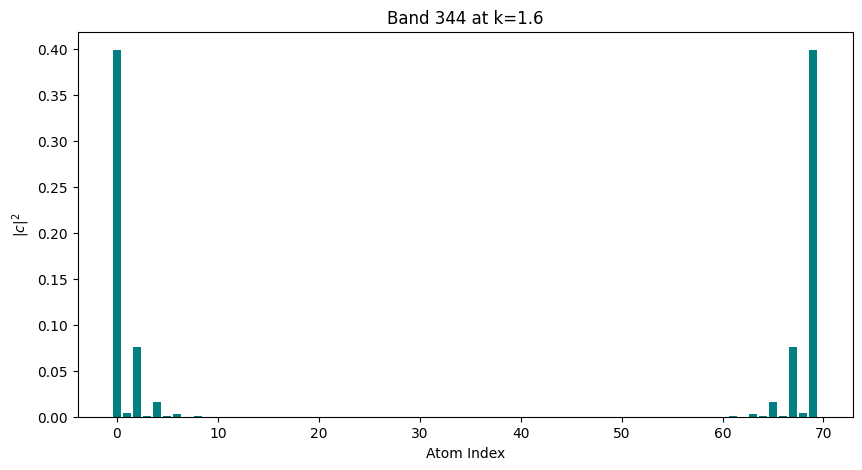

Total norm: 1.000000


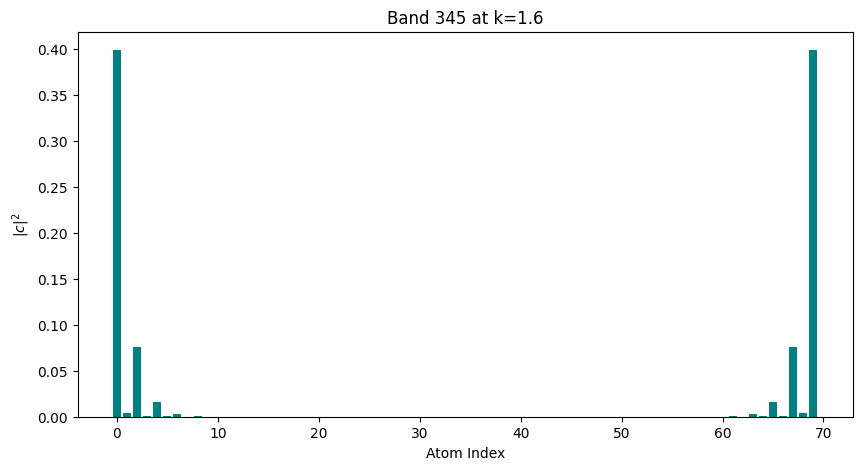

Total norm: 1.000000


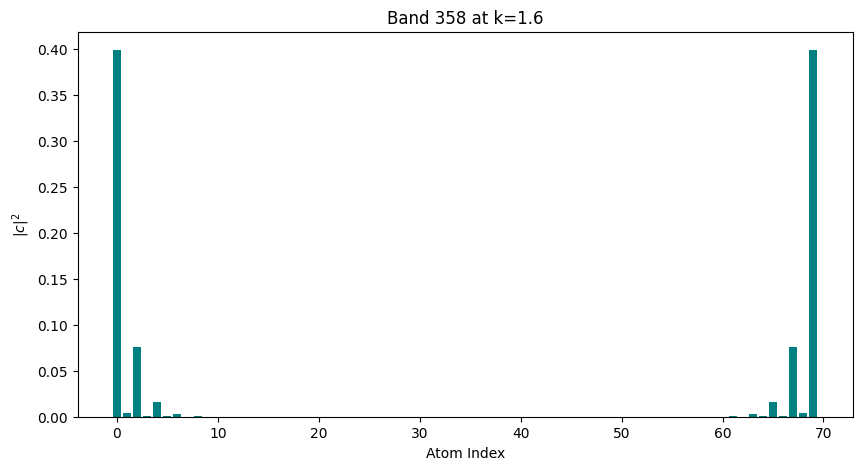

Total norm: 1.000000


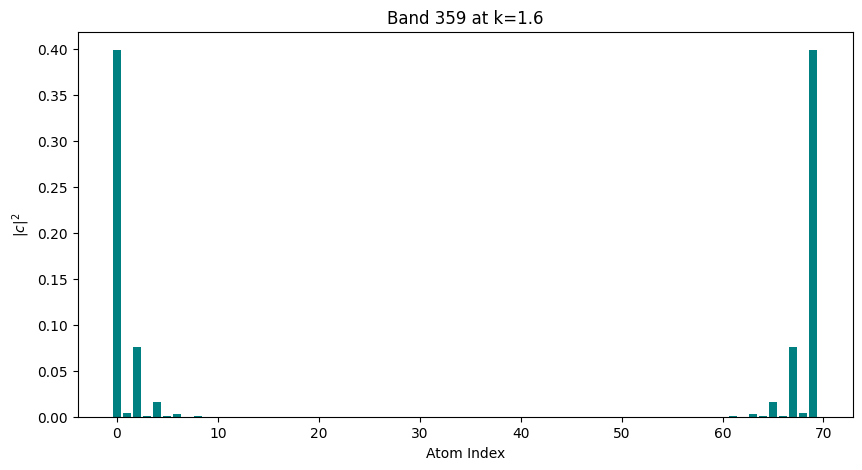

Total norm: 1.000000


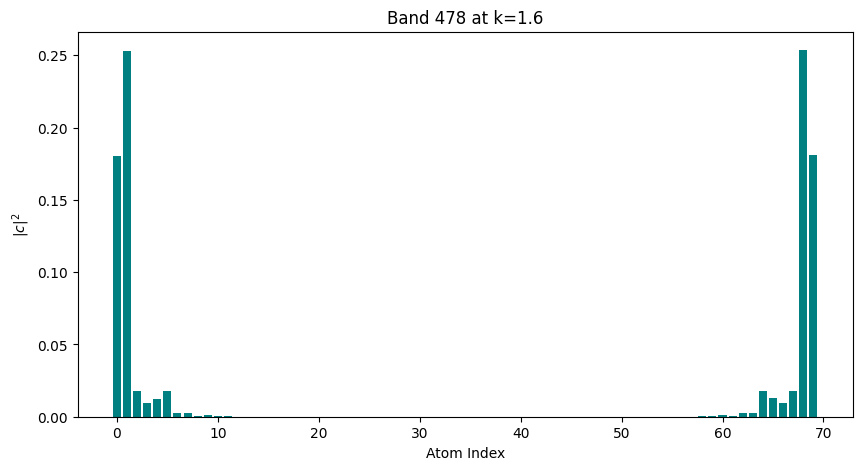

Total norm: 1.000000


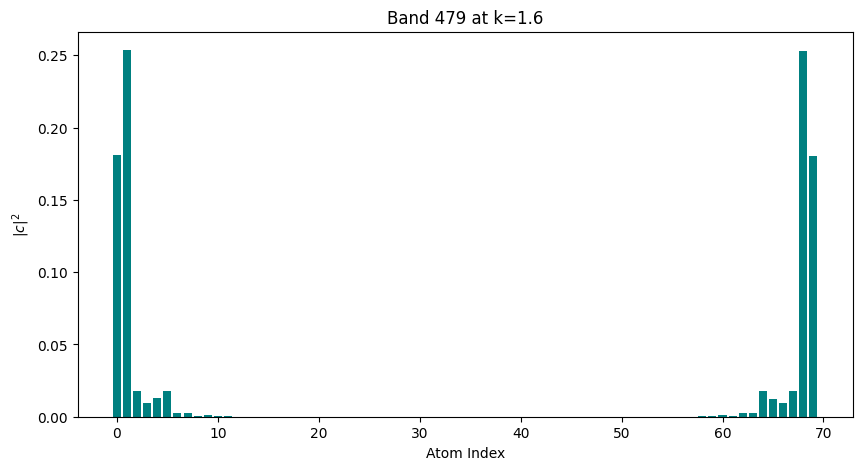

Total norm: 1.000000


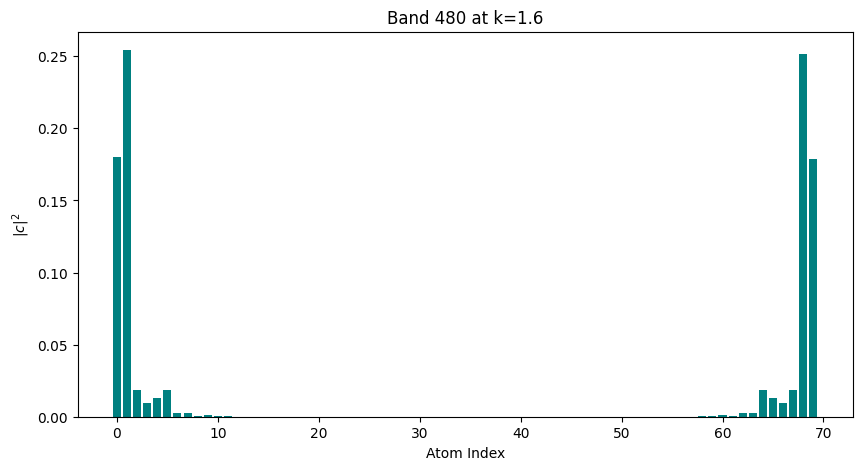

Total norm: 1.000000


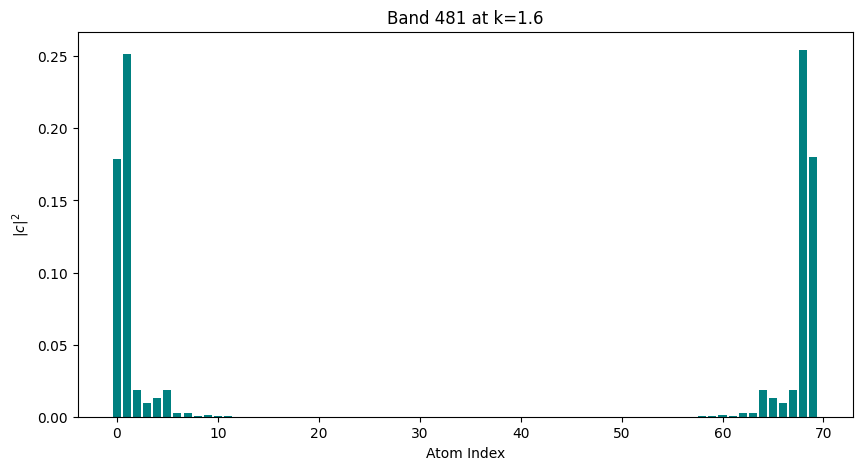

In [21]:
N_projections = len(tb_edge.coupled_states)
N_sites = len(tb_edge.sublattice_idxs)
N_bands = N_sites * N_projections

Psi_dict = tb_edge.band_structure_data["eigenvector_dict"]
for band in edge_bands:
    k_idx = np.argmin(np.abs(g.k_edge - k_target))
    Psi_k = Psi_dict[band][k_idx, :]
    total_norm = np.sum(np.abs(Psi_k)**2)
    print(f"Total norm: {total_norm:.6f}")
    n_atoms = len(tb_edge.sublattice_idxs)
    atomic_wavefunctions = {}
    atom_contributions = np.zeros(n_atoms)
    for i in range(n_atoms):
        start = i * N_projections
        end = start + N_projections
        orbital_block = Psi_k[start:end]  # Orbitals for atom i
        atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
        atomic_wavefunctions[i] = Psi_k[start:end] 

    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.bar(range(n_atoms), atom_contributions, color='teal')
    plt.xlabel("Atom Index")
    plt.ylabel(f"$|c|^2$")
    # plt.xlim(0, 10)
    plt.title(f"Band {band} at k={np.abs(g.k_edge[k_idx]):.1f}")
    plt.show()